## 11/27 photon absorption

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [3]:
import sklearn
from sklearn.decomposition import PCA

fogi timing

In [4]:
header = "D:/K_sunada/result/CDY152/"
# data = "/2023-11-13/2023-11-13T161943_0436012b-62_ab2_fogi_timing_sweep"
# dd = datadict_from_hdf5(header+data+"/data")

In [5]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [6]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [ ]:
timing = dd['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_timing = dd['fogi_timing']['values']

I = (timing.real)
Q = (timing.imag)

PCAtiming = PCA_transform(I, Q)

KeyError: 'fogi_timing'

In [ ]:
y = PCAtiming[0]
x = Fogi_timing

fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
ax1.set_xlabel('Timing (ns)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (arb. u.)', size='large')


ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")

plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.scatter(x-2000, y)
plt.show()

NameError: name 'PCAtiming' is not defined

In [ ]:
par_ini = {
    'amp': 50,
    'const':20,
    'center':850,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [ ]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result = model.fit(data = -y, params=params, freq = x)
result

In [ ]:
fig, ax = plt.subplots(dpi=80)
result.plot_fit(ax = ax)
plt.show()

In [ ]:
fogi_timing = "/2023-11-29/2023-11-29T152058_75aa338a-41_fogi_duration_sweep"
dd_fogi_timing = datadict_from_hdf5(header + fogi_timing +"/data")

In [ ]:
x_timing = dd_fogi_timing['fogi_duration']['values'][0:50]
y_timing = dd_fogi_timing['s11']['values'][0:50].real

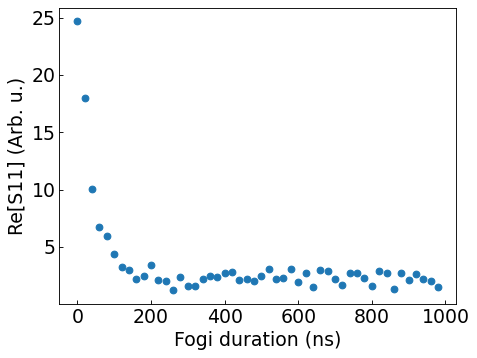

In [ ]:
fig, ax = plt.subplots(dpi=80)

#plt.title("fogi duration")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.scatter(x_timing ,y_timing)

plt.xlabel("Fogi duration (ns)")
plt.ylabel("Re[S11] (Arb. u.)")


plt.show()

freq

In [ ]:
data1 = "/2023-09-20/2023-09-20T135505_ddc12220-td_ab_ph_freq_sweep"
dd1 = datadict_from_hdf5(header+data1+"/data")

dd1


ValueError: Specified file does not exist.

In [ ]:
xs = []
ys = []

for i in range(31):
    ini = 46*i
    fin = 46*(1+i)
    x = dd1['fogi_frequency']['values'][ini:fin]
    ph = dd1['photon_frequency']['values'][ini:fin]
    y = dd1['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)


In [ ]:
plt.plot(xs[20], ys[20])
plt.show()

In [ ]:
timing = dd1['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_timing = dd1['fogi_timing']['values']

I = (timing.real)
Q = (timing.imag)

PCAfogi = PCA_transform(I, Q)
y = PCAfogi[0]
x = Fogi_timing

plt.plot(x, -y)
plt.show()

In [ ]:

par_ini = {
    'amp': 50,
    'const':20,
    'center':850,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result = model.fit(data = -y, params=params, freq = x)
result
fig, ax = plt.subplots(dpi=80)
result.plot_fit(ax = ax)
plt.show()

In [ ]:
data = "/2023-11-27/2023-11-27T124634_8f4b3f14-60_ab0_ph_freq_sweep"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['photon_frequency']['values']
y = dd['fogi_frequency']['values']
z = dd['s11']['values'].imag


In [ ]:
cm = plt.cm.get_cmap('Blues')
fig= plt.figure()
plt.rcParams["font.size"] = 15
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("F0g1 frequency (GHz)", size="large")
ax.set_ylabel("Photon frequency (GHz)", size="large")
# ax.set_ylim(5.658, 5.696)

maingraph = ax.pcolormesh( np.unique(x),np.unique(y), z.reshape(21, 21).T, vmin=min(z), vmax=max(z), cmap=cm, shading='auto')
plt.colorbar(maingraph)
plt.show()

photon-fogi freq

In [ ]:
data2 = "/2023-09-22/2023-09-22T141844_7ffc0276-td_ab_ph_freq_sweep"
dd2 = datadict_from_hdf5(header+data2+"/data")

In [ ]:
dd2

In [ ]:
xs = []
ys = []

for i in range(21):
    ini = 21*i
    fin = 21*(1+i)
    x = dd1['fogi_frequency']['values'][ini:fin]
    ph = dd1['photon_frequency']['values'][ini:fin]
    y = dd1['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)

# plt.plot(xs[10], ys[10])
# plt.show()

In [ ]:
timing = dd1['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_timing = dd1['fogi_timing']['values']

I = (timing.real)
Q = (timing.imag)

PCAfogi = PCA_transform(I, Q)
y = PCAfogi[0]
x = Fogi_timing

plt.plot(x, -y)
plt.show()

In [ ]:
par_ini = {
    'amp': 50,
    'const':20,
    'center':850,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result = model.fit(data = -y, params=params, freq = x)
result
fig, ax = plt.subplots(dpi=80)
result.plot_fit(ax = ax)
plt.show()
data = "/2023-09-20/2023-09-20T110244_c994cdb5-td_ab_ph_freq_sweep"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['photon_frequency']['values']
y = dd['fogi_frequency']['values']
z = dd['s11']['values'].imag


absorption rate - fogi & foton: square

In [7]:
header = "D:/K_sunada/result/CDY152/"
data = "/2023-11-30/2023-11-30T164720_b0bba080-72_JPA_ab_reflected_waveform"
#fogi: square, 1000ns, 0.9V, timing:photon+200ns
#photon: square, 1000ns, 0.08V

In [8]:
dd = datadict_from_hdf5(header+data+"/data")
# dd

In [9]:
x = dd['time']['values']
y = dd['waveform']['values']
y_base = dd['waveform_zero_fogi']['values']

In [10]:
def photon_energy(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    f = dd['fogi_frequency']['values'][i]
    x = dd['time']['values'][i]
    y_absorbed = dd['waveform']['values'][i] #- dd['waveform1']['values']
    y_base = dd['waveform_zero_fogi']['values'][i]
    offset=np.mean(y_absorbed)
    offset1=np.mean(y_base)

    E = 0
    E1 = 0
    t = 0
  
    for t in range(len(x)):
        E = E + ((y_absorbed[t]-offset)**2)*2
        E1 = E1 + ((y_base[t]-offset1)**2)*2
    rate = 1 - E/E1
    

    return rate

In [11]:
def waveform_show(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][i]
    y_absorbed = dd['waveform']['values'][i]# - dd['waveform1']['values']
    y_base = dd['waveform_zero_fogi']['values'][i]
    # y2 = dd['waveform2']['values']

    plt.rcParams["font.size"] = 15

    fig, (ax0, ax1) = plt.subplots(nrows=2)
    ax0.set_title("abosorption")
    ax0.set_xlabel('Time (ns)')
    ax0.set_ylabel('Waveform (V)')
    ax0.plot(x,  y_absorbed)#-np.mean(y_absorbed))
    ax0.tick_params(axis="x", direction="in")
    ax0.tick_params(axis="y", direction="in")
    # ax0.set_xlim( 0, 1000)
    ax0.set_ylim( 0.0005, 0.0009)

    ax1.set_title("no absorption")
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y_base)# - np.mean(y_base))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    # ax1.set_xlim( 0, 1000)    
    ax1.set_ylim( 0.0005, 0.0009)


    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()
    rate = photon_energy(data, i)[2] * 100
    return rate

## 73

In [12]:
def acquire_photon_energy(data):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    rates=[]

    f = dd['fogi_frequency']['values']
    for i in range(len(f)):
        x = dd['time']['values'][i]
        y_absorbed = dd['waveform']['values'][i] #- dd['waveform1']['values']
        y_base = dd['waveform_zero_fogi']['values'][i]
        offset=np.mean(y_absorbed)
        offset1=np.mean(y_base)
        
        E = 0
        E1 = 0
        t = 0
    
        for t in range(len(x)):
            E = E + ((y_absorbed[t]-offset)**2)*2
            E1 = E1 + ((y_base[t]-offset1)**2)*2
        rate = 1 - E/E1

        rates = np.append(rates, rate * 100)
    

    return rates

In [13]:
def waveform_show1(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    f = dd['fogi_frequency']['values'][i]
    x = dd['time']['values'][i]
    y_absorbed = dd['waveform']['values'][i]# - dd['waveform1']['values']
    y_base = dd['waveform_zero_fogi']['values'][i]
    # y2 = dd['waveform2']['values']

    plt.rcParams["font.size"] = 15
    fig = plt.figure(figsize=(10, 10))
    fig, (ax0, ax1) = plt.subplots(nrows=2)
    # ax0.set_title("abosorption")
    ax0.set_xlabel('Time (ns)')
    ax0.set_ylabel('Waveform (V)')
    ax0.plot(x,  y_absorbed)#-np.mean(y_absorbed))
    ax0.tick_params(axis="x", direction="in")
    ax0.tick_params(axis="y", direction="in")
    # ax0.set_xlim( 0, 1000)
    ax0.set_ylim( -0.0005, 0.002)

    # ax1.set_title("no absorption")
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y_base)# - np.mean(y_base))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    # ax1.set_xlim( 0, 1000)    
    ax1.set_ylim( -0.0005, 0.002)


    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()
    rate = photon_energy(data, i) * 100

    plt.tight_layout()
    return rate , f

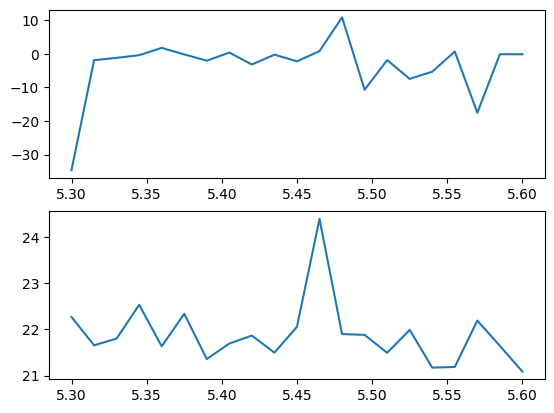

In [14]:
# photon amp 0.3
data03 = "/2023-11-30/2023-11-30T221546_92b8b02b-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data03+"/data")
f = dd['fogi_frequency']['values']
qstate = dd['qstate']['values'].real
ab_rate = acquire_photon_energy(data03)
fig, (ax1, ax2) = plt.subplots(nrows=2)

ax1.plot(f, ab_rate)
ax2.plot(f, qstate)
plt.show()

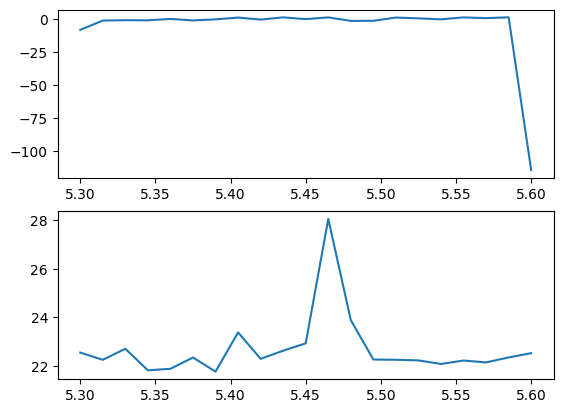

In [15]:
# photon amp 0.5
data05 = "/2023-11-30/2023-11-30T224125_27df8467-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data05+"/data")
f = dd['fogi_frequency']['values']
qstate = dd['qstate']['values'].real
ab_rate = acquire_photon_energy(data05)
fig, (ax1, ax2) = plt.subplots(nrows=2)

ax1.plot(f, ab_rate)
ax2.plot(f, qstate)
plt.show()

<Figure size 1000x1000 with 0 Axes>

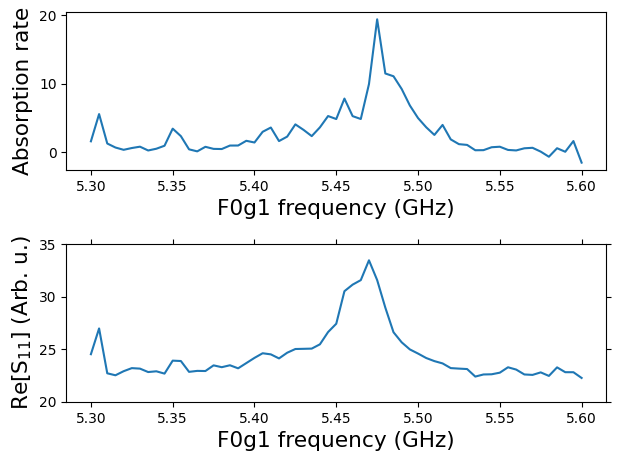

In [16]:
# photon amp 0.9
data09 = "/2023-12-01/2023-12-01T001434_2b44bf1b-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data09+"/data")
f = dd['fogi_frequency']['values']
qstate = dd['qstate']['values'].real
ab_rate = acquire_photon_energy(data09)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")


ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

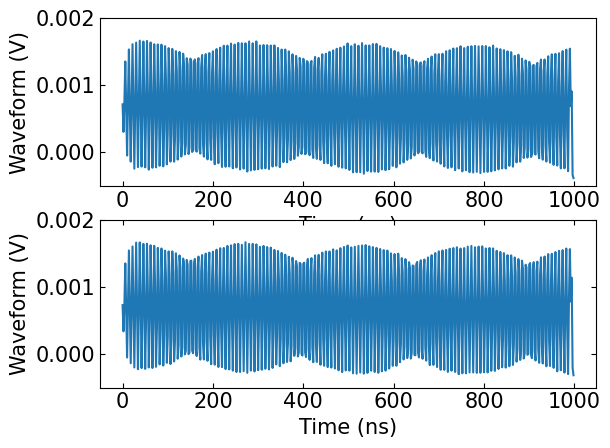

(0.562268118827558, 5.325)

<Figure size 640x480 with 0 Axes>

In [17]:
waveform_show1(data09, 5)

<Figure size 1000x1000 with 0 Axes>

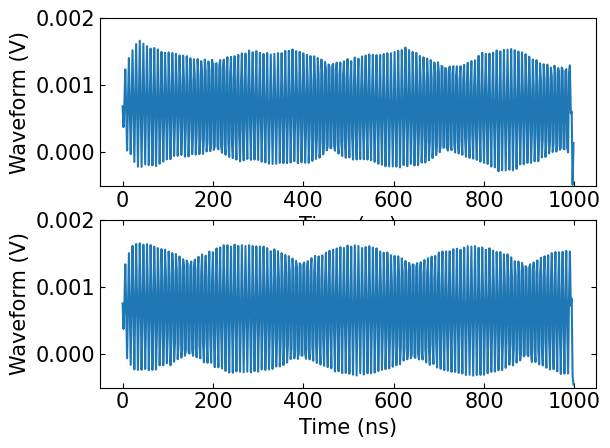

(19.411166385807952, 5.475)

<Figure size 640x480 with 0 Axes>

In [27]:
waveform_show1(data09, 35)

In [20]:
## ph 1.25 V 500ns

data09500ns = "/2023-12-01/2023-12-01T134319_264140b0-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data09500ns+"/data")
f = dd['fogi_frequency']['values']
qstate = dd['qstate']['values'].real
ab_rate = acquire_photon_energy(data09500ns)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")


ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()

RuntimeError: Lock file remained for longer than timeout time

<Figure size 1000x1000 with 0 Axes>

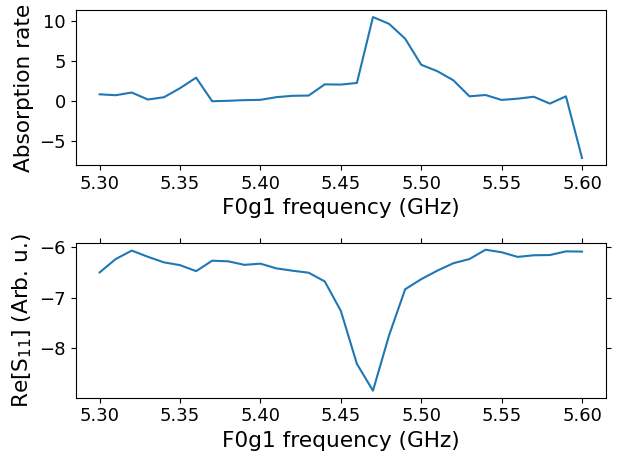

In [21]:
## 0.9 V 500ns
data09500ns = "/2023-12-01/2023-12-01T082617_dc3d7f2b-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data09500ns+"/data")
f = dd['fogi_frequency']['values']
qstate = dd['qstate']['values'].real
ab_rate = acquire_photon_energy(data09500ns)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")


ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

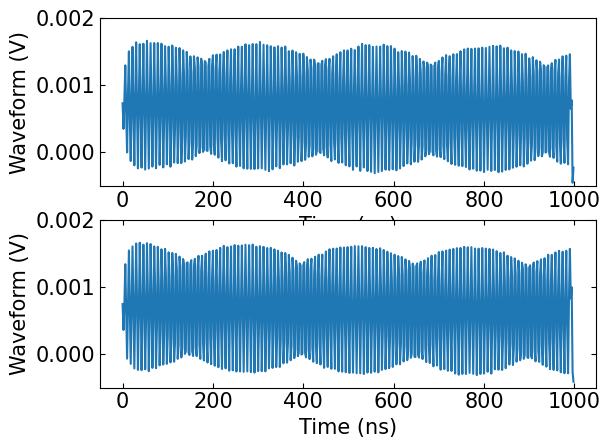

((0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,
  0.00044726142251302805,
  0.040264812606825684,
  0.0004292525251492787,


<Figure size 640x480 with 0 Axes>

In [17]:
waveform_show1(data09500ns, 25)

<Figure size 1000x1000 with 0 Axes>

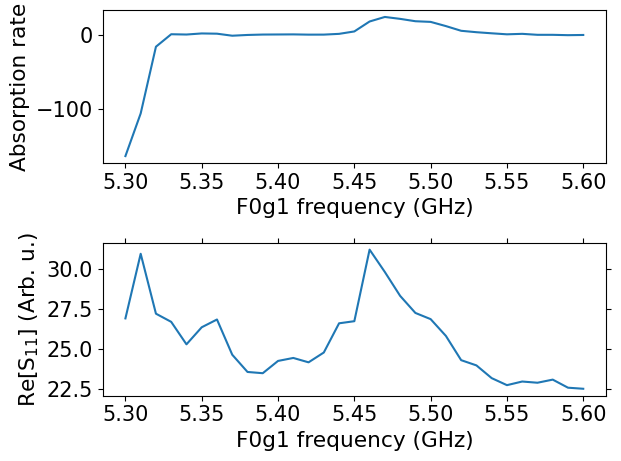

In [28]:
data09500ns = "/2023-12-01/2023-12-01T111636_a774d802-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data09500ns+"/data")
f = dd['fogi_frequency']['values']
qstate = dd['qstate']['values'].real
ab_rate = acquire_photon_energy(data09500ns)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")


ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()

fogi freq / photon amp sweep (3D)

In [388]:
def acquire_photon_energy3D(data, a): #i: photon amplitude id
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    rates=[]

    waveform = []
    waveform_zero_fogi = []
    time = []
    fogi_freq = []
    for j in range(4):
        ts = []
        ws = []
        wfs = []
        fs = []
        for i in range(16):
            k = i* 4 +j
            t = dd['time']['values'][k]
            ts.append(t)
            w = dd['waveform']['values'][k]
            ws.append(w)
            wf = dd['waveform_zero_fogi']['values'][k]
            wfs.append(wf)
            f = dd['fogi_frequency']['values'][k]
            fs.append(f)
        time.append(ts)
        waveform.append(ws)
        waveform_zero_fogi.append(wfs)
        fogi_freq.append(fs)
    
    n = 0
    for n in range(len(fogi_freq[0])):
        x = time[a][n]
        y_absorbed = waveform[a][n]
        y_base = waveform_zero_fogi[a][n]
        offset=np.mean(y_absorbed)
        offset1=np.mean(y_base)
        
        E = 0
        E1 = 0
        t = 0
    
        for t in range(len(x)):
            E = E + ((y_absorbed[t]-offset)**2)*2
            E1 = E1 + ((y_base[t]-offset1)**2)*2
        rate = 1 - E/E1

        rates = np.append(rates, rate * 100)
    

    return rates

In [421]:
def waveform_show3D(data, a, f): #a: ph amp, i: fogi freq
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    
    waveform = []
    waveform_zero_fogi = []
    time = []
    fogi_freq = []
    for j in range(4):
        ts = []
        ws = []
        wfs = []
        fs = []
        for i in range(16):
            k = i* 4 +j
            t = dd['time']['values'][k]
            ts.append(t)
            w = dd['waveform']['values'][k]
            ws.append(w)
            wf = dd['waveform_zero_fogi']['values'][k]
            wfs.append(wf)
            fr = dd['fogi_frequency']['values'][k]
            fs.append(fr)
        time.append(ts)
        waveform.append(ws)
        waveform_zero_fogi.append(wfs)
        fogi_freq.append(fs)

    
    freq = fogi_freq[a][f]
    x = time[a][f]
    y_absorbed = waveform[a][f]
    y_base = waveform_zero_fogi[a][f]
    # y2 = dd['waveform2']['values']
    

    plt.rcParams["font.size"] = 15
    fig = plt.figure(figsize=(10, 10))
    fig, (ax0, ax1) = plt.subplots(nrows=2)
    # ax0.set_title("abosorption")
    ax0.set_xlabel('Time (ns)')
    ax0.set_ylabel('Waveform (V)')
    ax0.plot(x,  y_absorbed)#-np.mean(y_absorbed))
    ax0.tick_params(axis="x", direction="in")
    ax0.tick_params(axis="y", direction="in")
    # ax0.set_xlim( 0, 1000)
    ax0.set_ylim( 0.0002, 0.0012)

    # ax1.set_title("no absorption")
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y_base)# - np.mean(y_base))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    # ax1.set_xlim( 0, 1000)    
    ax1.set_ylim(0.0002, 0.0012)


    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()
    rate = acquire_photon_energy3D(data, a)[f]

    plt.tight_layout()
    return rate , freq

<Figure size 1000x1000 with 0 Axes>

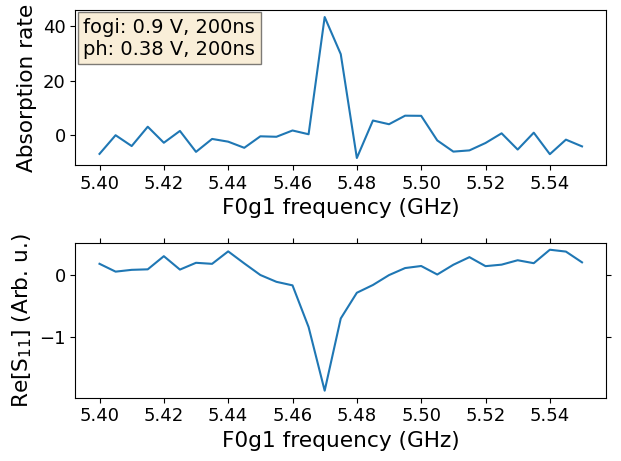

5.47 43.335238490778025


In [372]:
#ph:0.38 / fogi: 0.9V, 200ns
data121 = "/2023-12-01/2023-12-01T163819_98d9fa2a-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data121+"/data")

fogi_freq = []
q_state =[]
for j in range(6):
    qs = []
    fs = []
    for i in range(31):
        k = i* 6 +j
        f = dd['fogi_frequency']['values'][k]
        fs.append(f)
        q = dd['qstate']['values'][k].real
        qs.append(q)
    fogi_freq.append(fs)
    q_state.append(qs)
    
a = 1  ##photon amp id
f = fogi_freq[a]
qstate = q_state[a]
ab_rate = acquire_photon_energy3D(data121, a)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 200ns',
    'ph: 0.38 V, 200ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
         verticalalignment='top', bbox=props1)



ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)


plt.tight_layout()
plt.show()
print(f[14], ab_rate[14])

<Figure size 1000x1000 with 0 Axes>

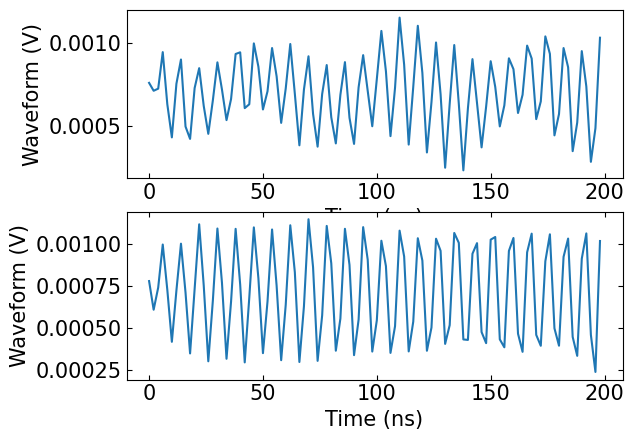

(43.335238490778025, 5.47)

<Figure size 640x480 with 0 Axes>

In [373]:
waveform_show3D(data121, 1, 14)

<Figure size 1000x1000 with 0 Axes>

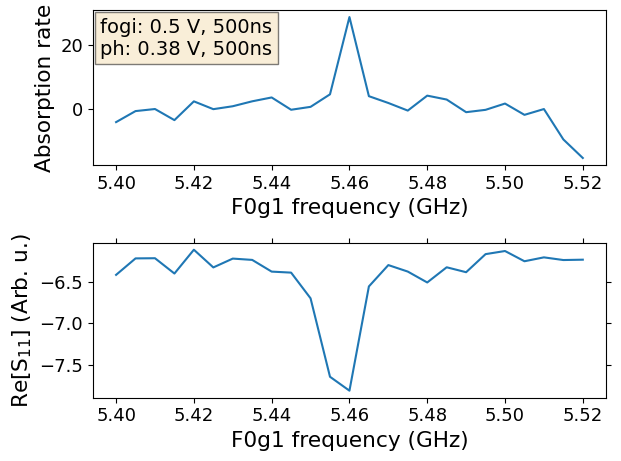

5.46 28.85298293137829


In [377]:
#ph:0.38 / fogi: 0.5V, 500ns
data121 = "/2023-12-04/2023-12-04T091617_579ddef8-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data121+"/data")

fogi_freq = []
q_state =[]
for j in range(6):
    qs = []
    fs = []
    for i in range(31):
        k = i* 6 +j
        f = dd['fogi_frequency']['values'][k]
        fs.append(f)
        q = dd['qstate']['values'][k].real
        qs.append(q)
    fogi_freq.append(fs)
    q_state.append(qs)
    
a = 1  ##photon amp id
f = fogi_freq[a]
qstate = q_state[a]
ab_rate = acquire_photon_energy3D(data121, a)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
textstr1 = '\n'.join((
    'fogi: 0.5 V, 500ns',
    'ph: 0.38 V, 500ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f[0: 25], ab_rate[0: 25])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
         verticalalignment='top', bbox=props1)


ax2.plot(f[0: 25], qstate[0: 25])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()

print(f[12], ab_rate[12])

<Figure size 1000x1000 with 0 Axes>

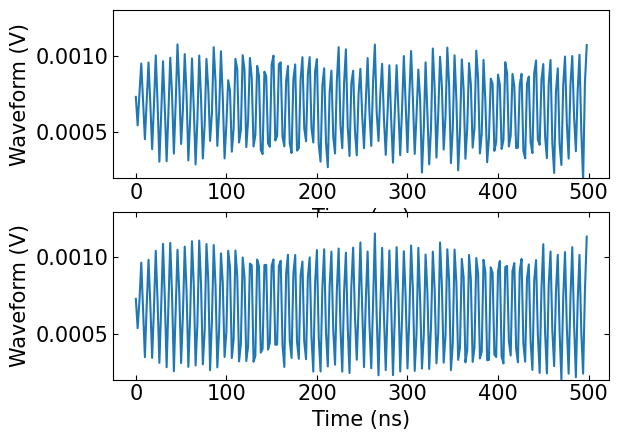

(28.85298293137829, 5.46)

<Figure size 640x480 with 0 Axes>

In [382]:
waveform_show3D(data121, 1, 12)

<Figure size 1000x1000 with 0 Axes>

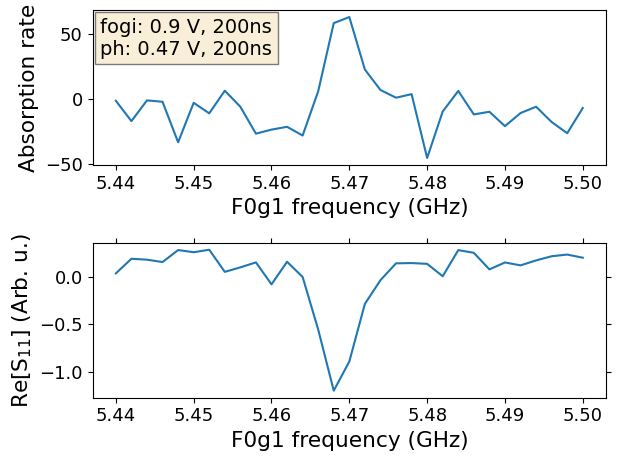

5.482 -9.502703923803125


In [364]:
#ph:0.38 / fogi: 0.9V, 200ns
data = "/2023-12-04/2023-12-04T122504_b77ecea0-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for j in range(4):
    qs = []
    fs = []
    for i in range(31):
        k = i* 4 +j
        f = dd['fogi_frequency']['values'][k]
        fs.append(f)
        q = dd['qstate']['values'][k].real
        qs.append(q)
    fogi_freq.append(fs)
    q_state.append(qs)
    
a = 0  ##photon amp id
f = fogi_freq[a]
qstate = q_state[a]
ab_rate = acquire_photon_energy3D(data, a)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 200ns',
    'ph: 0.47 V, 200ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
         verticalalignment='top', bbox=props1)


ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()

print(f[21], ab_rate[21])

<Figure size 1000x1000 with 0 Axes>

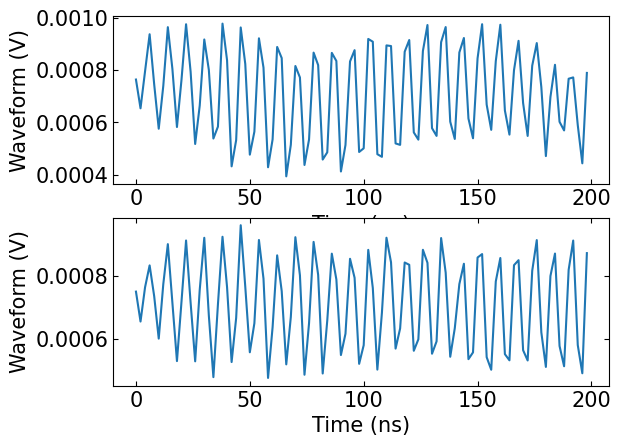

(-45.318343102535195, 5.48)

<Figure size 640x480 with 0 Axes>

In [366]:
waveform_show3D(data, 0, 20)

<Figure size 1000x1000 with 0 Axes>

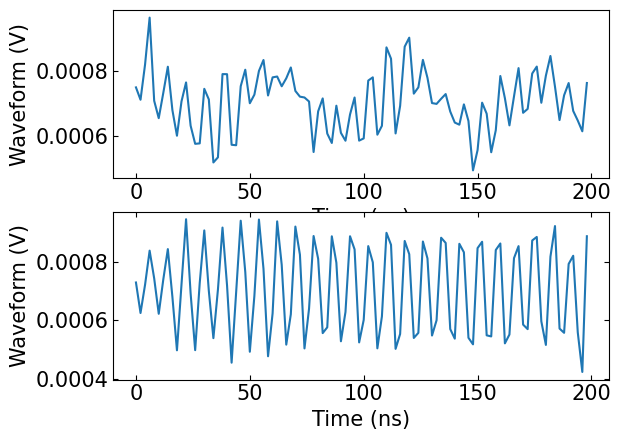

(63.27269046678381, 5.470000000000001)

<Figure size 640x480 with 0 Axes>

In [365]:
waveform_show3D(data, 0, 15)

<Figure size 1000x1000 with 0 Axes>

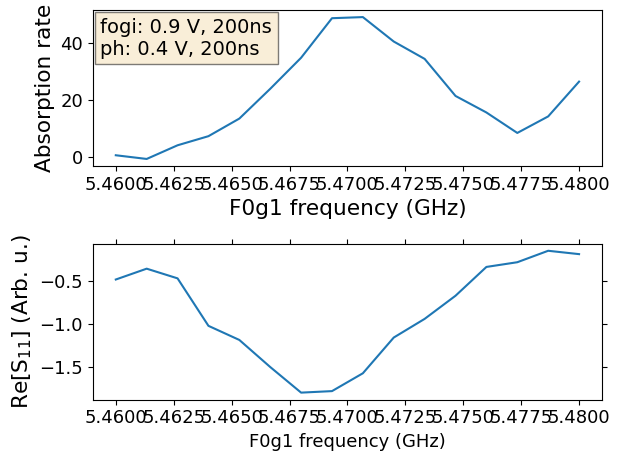

5.470666666666667 49.2396518825118


In [418]:
#ph:0.38 / fogi: 0.9V, 200ns
data = "/2023-12-04/2023-12-04T154003_f426632a-73_JPA_ab_waveform_qstate"
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for j in range(4):
    qs = []
    fs = []
    for i in range(16):
        k = i* 4 +j
        f = dd['fogi_frequency']['values'][k]
        fs.append(f)
        q = dd['qstate']['values'][k].real
        qs.append(q)
    fogi_freq.append(fs)
    q_state.append(qs)
    
a = 3  ##photon amp id
f = fogi_freq[a]
qstate = q_state[a]
ab_rate = acquire_photon_energy3D(data, a)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 200ns',
    'ph: 0.4 V, 200ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
         verticalalignment='top', bbox=props1)


ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)')
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()

print(f[8], ab_rate[8])

<Figure size 1000x1000 with 0 Axes>

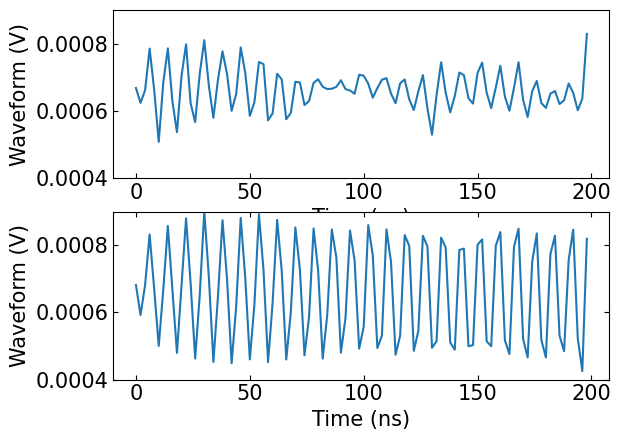

(83.79021556034874, 5.469333333333333)

<Figure size 640x480 with 0 Axes>

In [404]:
waveform_show3D(data, 1, 7)

<Figure size 1000x1000 with 0 Axes>

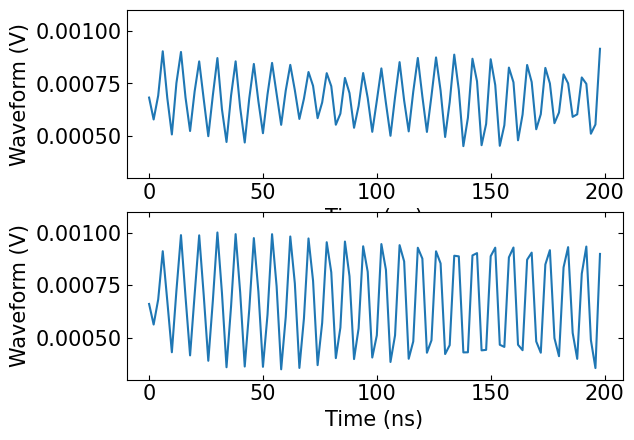

(67.36455290020133, 5.469333333333333)

<Figure size 640x480 with 0 Axes>

In [415]:
waveform_show3D(data, 2, 7)

<Figure size 1000x1000 with 0 Axes>

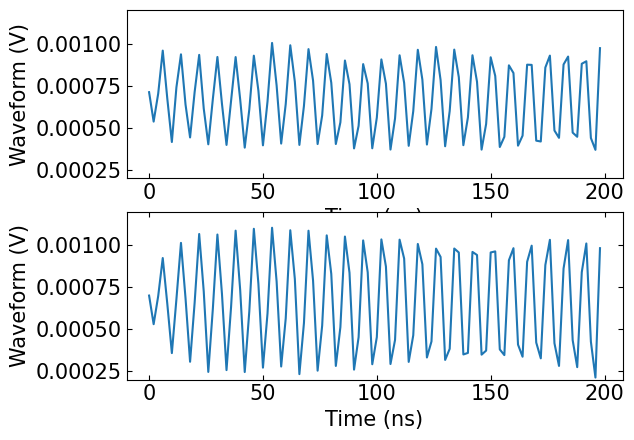

(49.2396518825118, 5.470666666666667)

<Figure size 640x480 with 0 Axes>

In [422]:
waveform_show3D(data, 3, 8)

## 72

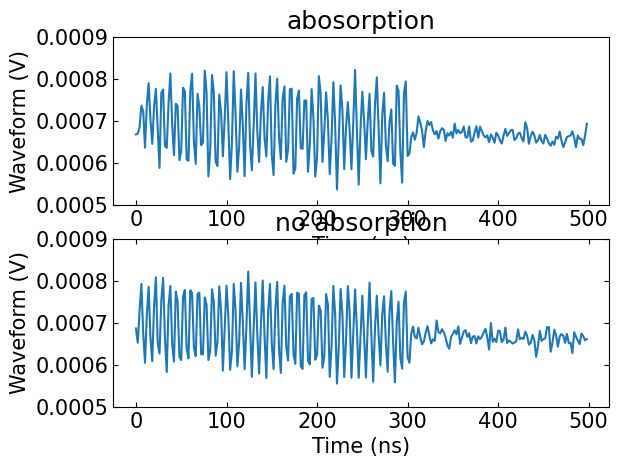

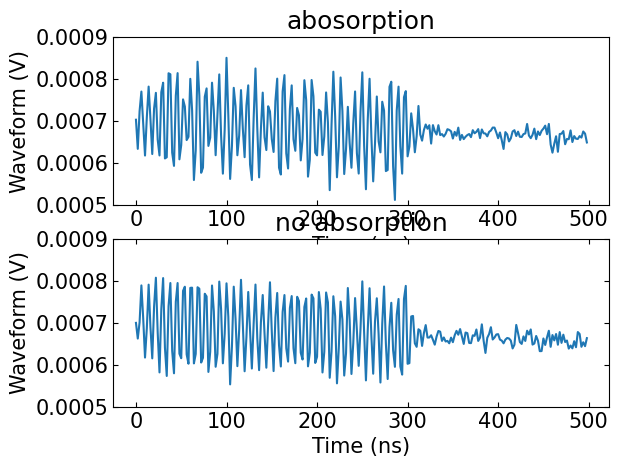

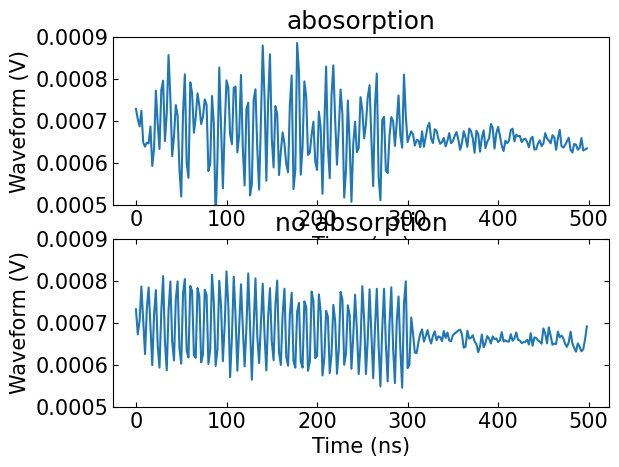

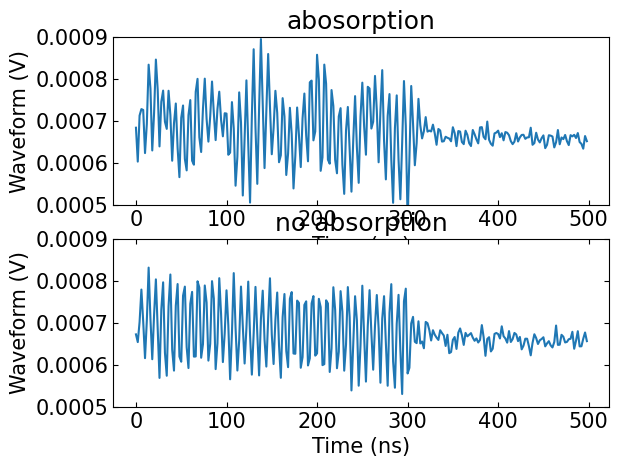

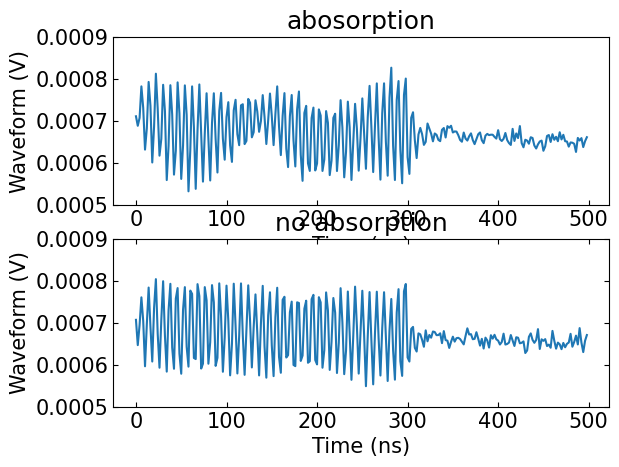

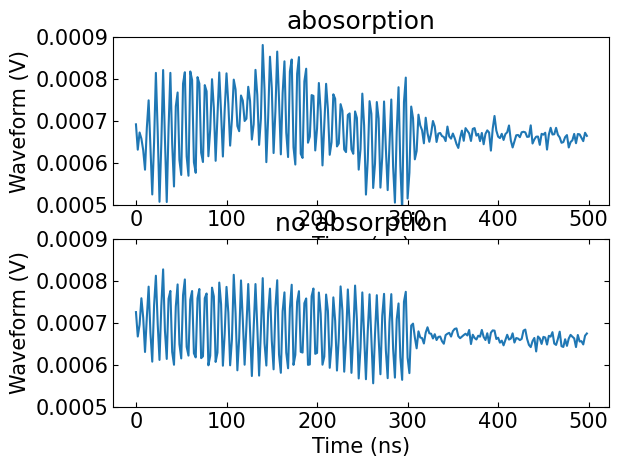

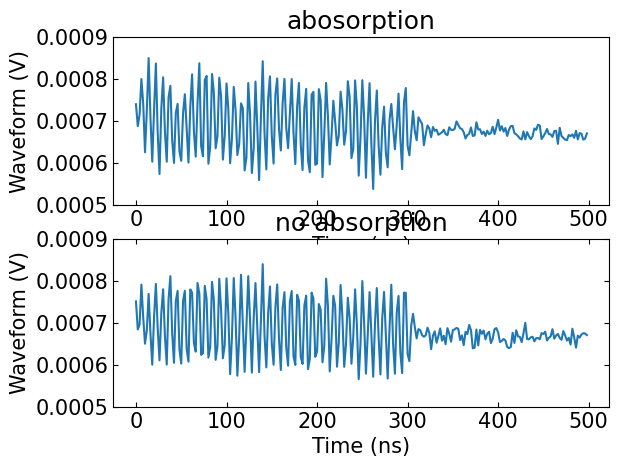

(-1.3912215123096594,
 -2.7807288925669083,
 -5.625025041932519,
 -4.273744915339761,
 5.905343555319531,
 -15.54528978336509,
 0.2873419893464124)

In [ ]:
# photon amp 0.1
waveform_show(data, 0), waveform_show(data, 1), waveform_show(data, 2), waveform_show(data, 3), waveform_show(data, 4), waveform_show(data, 5), waveform_show(data, 6)

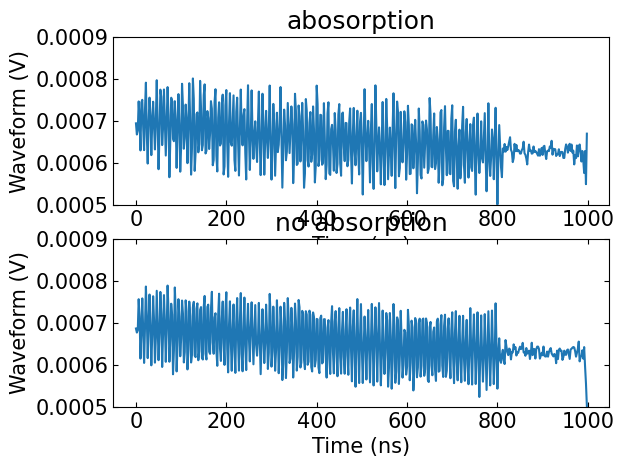

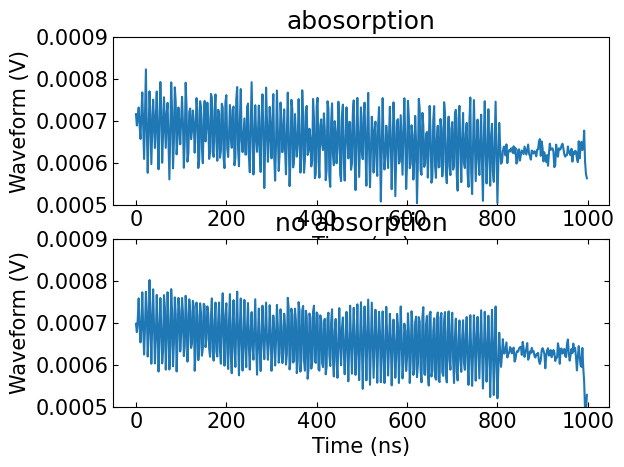

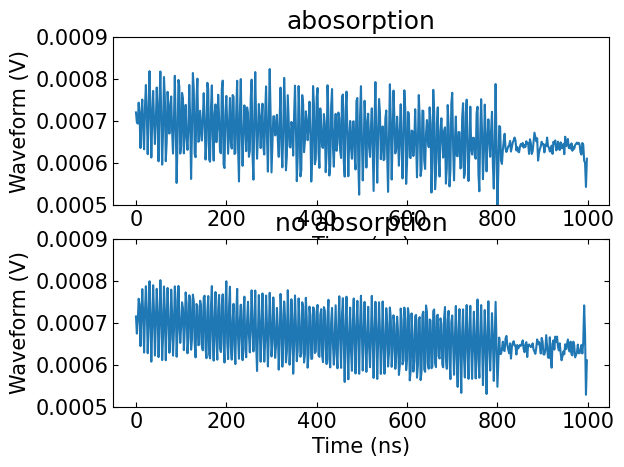

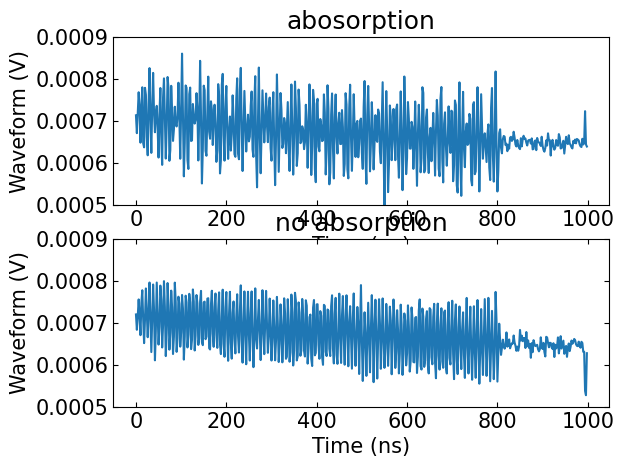

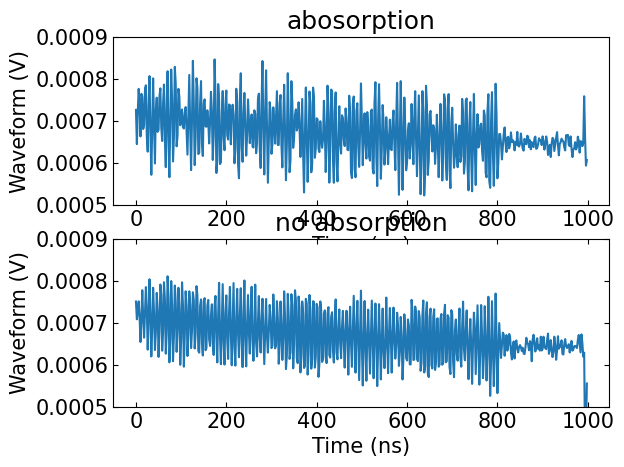

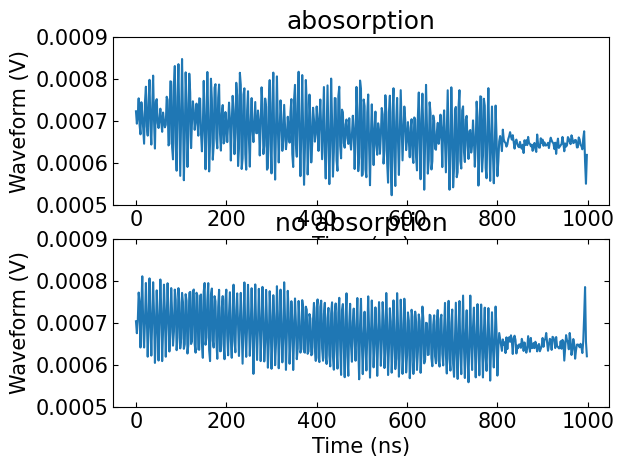

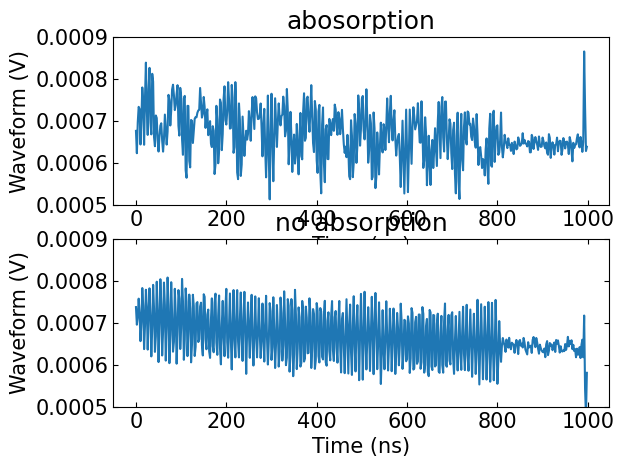

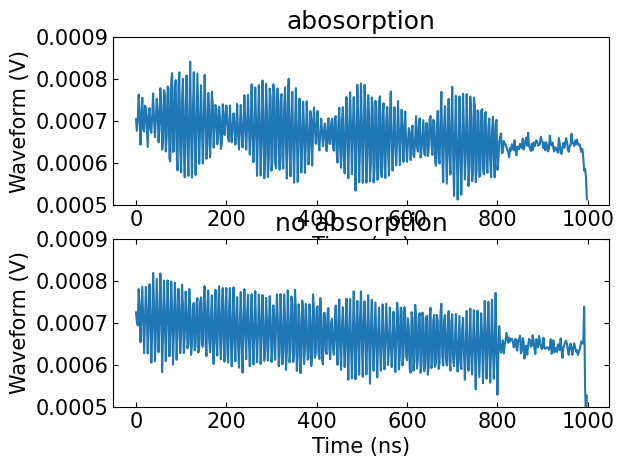

(-2.114829920479311,
 -3.733694550442479,
 -4.346771816923756,
 -7.952137146470739,
 -5.049053396660952,
 -2.4438397610337503,
 8.01875269487946,
 -1.0082754483428547)

In [ ]:
# photon amp 0.08
data1 = "/2023-11-30/2023-11-30T174607_e751949e-72_JPA_ab_reflected_waveform"
waveform_show(data1, 0), waveform_show(data1, 1), waveform_show(data1, 2), waveform_show(data1, 3), waveform_show(data1, 4), waveform_show(data1, 5), waveform_show(data1, 6), waveform_show(data1, 7)

Previous measurment

In [ ]:
data1 = "/2023-09-22/2023-09-22T143739_24d1513f-td_ab_reflection"
#fogi: square, 1000ns, 0.9V, timing:photon-830ns
#photon: square, 800ns, 0.03V

In [ ]:
photon_energy(data1)

In [ ]:
data2 = "/2023-09-21/2023-09-21T094857_a5b6aa1b-td_ab_reflection"
#fogi: square, 1000ns, 0.9V, timing:photon+0ns
#photon: square, 1000ns, 0.08V
photon_energy(data2)

absorption rate - fogi: square & photon: time reversed

In [ ]:
data = "/2023-09-21/2023-09-21T102917_480c9226-td_photon_generation"
#fogi: square, 1000ns, 0.9V

dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values']
y = dd['waveform']['values']



In [ ]:
fig, (ax0) = plt.subplots(nrows=1)
ax0.set_xlabel('time(ns)')
ax0.set_ylabel('waveform(V)')
ax0.plot(x,  y[::-1])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
#    ax0.set_ylim(-0.0005, 0.0017)

plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
plt.show()

In [ ]:
header = "D:/K_sunada/result/CDY148/"
data_ph = "/2023-09-21/2023-09-21T102917_480c9226-td_photon_generation"
dd = datadict_from_hdf5(header+data_ph+"/data")
y_ph = dd['waveform']['values']

def y_lerp(y): #sennkeihokann
    y_new = []
    for i in range(len(y)-1):
        y_new.append(y[i])
        y_new.append((y[i]+y[i+1])/2)
    y_new.append(y[len(y)-1])
    return y_new-np.mean(y)

In [ ]:
fig, (ax0) = plt.subplots(nrows=1)
ax0.set_xlabel('time(ns)')
ax0.set_ylabel('waveform(V)')
ax0.plot(y_lerp(x),  y_lerp(y_ph[::-1]))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")

plt.show()

In [ ]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [ ]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [ ]:
header = "D:/K_Sunada/result/CDY152/"


photon: 10.299 GHz

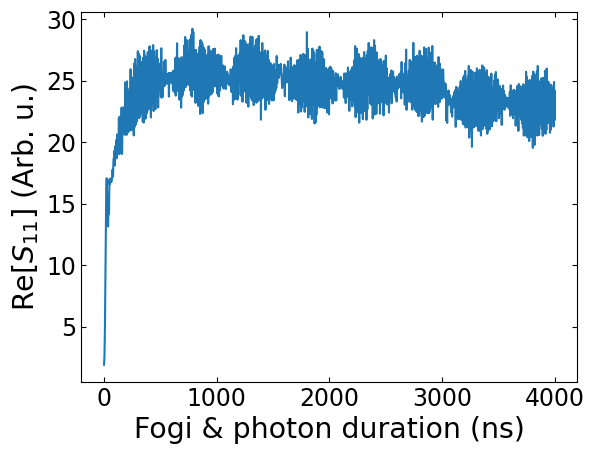

In [ ]:
amp = "/2023-11-29/2023-11-29T120833_948712e3-62_ab2_fogi_duration_sweep"
dd_amp = datadict_from_hdf5(header + amp +"/data")
Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['fogi_timing']['values']
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)

PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp
fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Fogi & photon duration (ns)', size='large')
ax1.set_ylabel('Re[$S_{11}$] (Arb. u.)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, I_amp)#PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

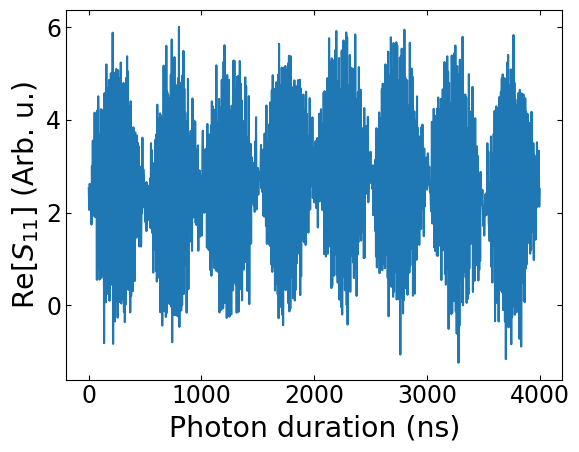

In [ ]:
onlyph = "/2023-11-29/2023-11-29T112841_02c8e40f-62_ab2_fogi_duration_sweep"
dd_ph = datadict_from_hdf5(header + onlyph +"/data")
Rabi_amp = dd_ph['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_ph['fogi_timing']['values']
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)

PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp
fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Photon duration (ns)', size='large')
ax1.set_ylabel('Re[$S_{11}$] (Arb. u.)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, I_amp)#PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

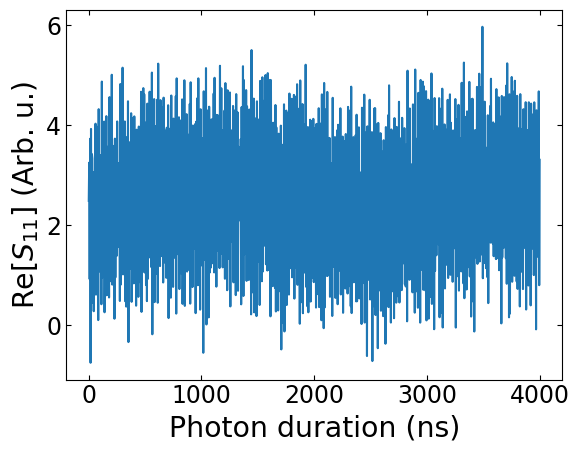

In [ ]:
amp = "/2023-11-29/2023-11-29T123137_cd49e38f-62_ab2_fogi_duration_sweep"
dd_amp = datadict_from_hdf5(header + amp +"/data")
Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['fogi_timing']['values']
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)

PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp
fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Photon duration (ns)', size='large')
ax1.set_ylabel('Re[$S_{11}$] (Arb. u.)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, I_amp)#PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

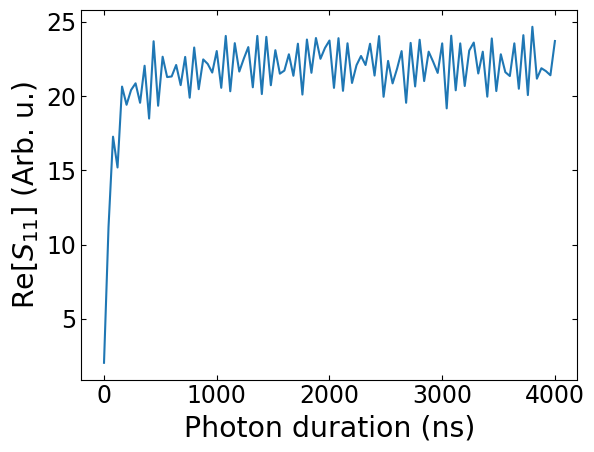

In [ ]:
amp = "/2023-11-29/2023-11-29T133028_0600139c-62_ab2_fogi_duration_sweep"
dd_amp = datadict_from_hdf5(header + amp +"/data")
Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['fogi_timing']['values']
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)

PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp
fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Photon duration (ns)', size='large')
ax1.set_ylabel('Re[$S_{11}$] (Arb. u.)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, I_amp)#PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

In [ ]:
par_ini= {
    'amp': 3,
    'phi0':np.pi/2,
    'detun':1/1000,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [ ]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result = model.fit(data = PCA_amp[0], params = params, delay = x)
result

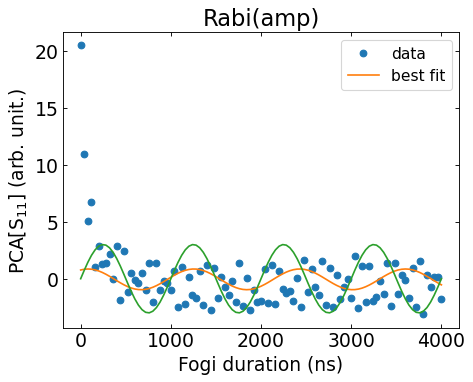

In [ ]:

fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(amp)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x,result.init_fit)

plt.rcParams["font.size"] = 14
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

# plt.plot(x_t1,res1.init_fit, lult_tabel='init fit')

# ax.set_xlim(0, 250000)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Fogi duration (ns)', size='large')
ax.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')

ax.legend()
plt.show()

In [ ]:
(np.pi/2-1.48655475)/9.9887e-04

84.33687746643359